In [1]:
# statsbomb_shots.py
from pathlib import Path
import pandas as pd
import numpy as np
from nodes.utils import collect_all_shots, plot_shots
from nodes.model import SimpleXGModel, AdvancedXGModel
import matplotlib.pyplot as plt
import joblib
from nodes.plot import generate_xg_heatmap
import pandas as pd

In [2]:
# import os

# # Go one level higher
# os.chdir("../..")

# # Check current directory
# print(os.getcwd())

### 1. Collect all shots

In [3]:
# OPEN_DATA_DIR = Path("open-data/data")  # adjust if different
# EVENTS_DIR = OPEN_DATA_DIR / "events"

In [4]:
# shots_df = collect_all_shots(EVENTS_DIR)

In [5]:
# shots_df.shape

In [6]:
# competitions

In [7]:
# shots_df.to_csv("shots.csv", index=False)

### 2. Print some of them

In [8]:
# shots_df.iloc[0]

In [9]:
# fig, ax = plot_shots(shots_df, max_shots=10)
# plt.show()

In [10]:
# player_shots = shots_df[shots_df['player_name'] == 'Leandro Greco']
# fig, ax = plot_shots(player_shots)
# plt.show()

### 3. First model

In [11]:
# import os
# os.chdir("../..")
# print(os.getcwd())

In [12]:
shots_df=pd.read_csv("results/shots_after_eda_v2.csv")

In [13]:
# shots_df[shots_df['player_name']=='Lionel Andrés Messi Cuccittini'].iloc[0]

In [14]:
shots_df.shape

(87215, 16)

### 3.1 Simple model

In [15]:
# 1. Create and train the model
xg_model_simple = SimpleXGModel()
metrics = xg_model_simple.train(shots_df)

MODEL TRAINING RESULTS
Accuracy: 0.8906
ROC AUC: 0.7971
Log Loss: 0.2880
Actual Goal Rate: 0.1123
Predicted Goal Rate: 0.1124

TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
technique_Backheel            : -1.5425
technique_Lob                 : +1.4909
bodypart_Head                 : -1.4281
technique_Overhead Kick       : -1.2794
technique_Diving Header       : +1.1728
technique_Volley              : -0.6608
bodypart_Other                : -0.6497
angle_to_goal                 : +0.5889
bodypart_Right Foot           : +0.5856
technique_Half Volley         : -0.5109
--------------------------------------------------


In [16]:
xg_model_simple._show_feature_importance()


TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
technique_Backheel            : -1.5425
technique_Lob                 : +1.4909
bodypart_Head                 : -1.4281
technique_Overhead Kick       : -1.2794
technique_Diving Header       : +1.1728
technique_Volley              : -0.6608
bodypart_Other                : -0.6497
angle_to_goal                 : +0.5889
bodypart_Right Foot           : +0.5856
technique_Half Volley         : -0.5109
--------------------------------------------------


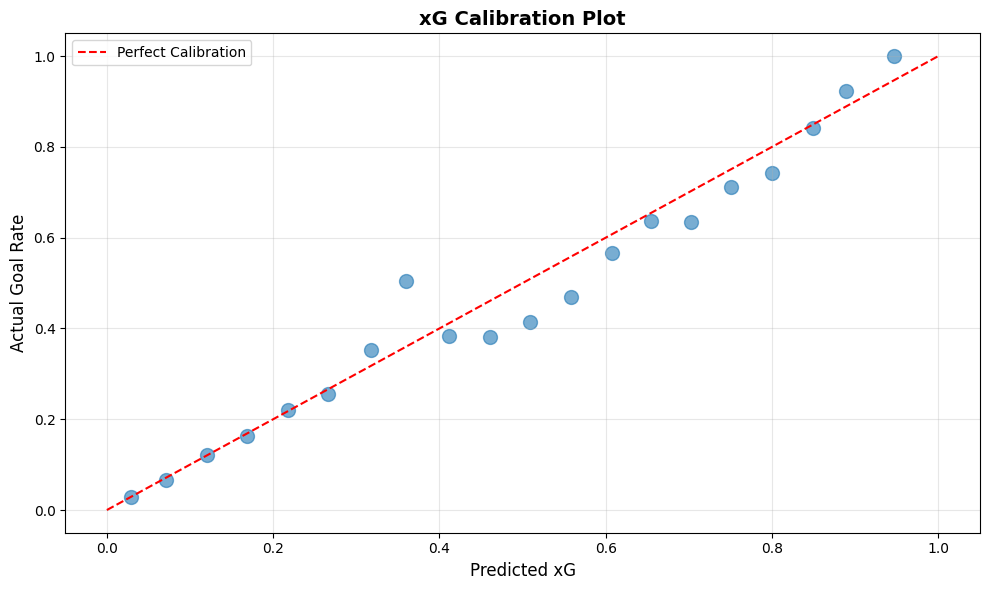

In [17]:
xg_model_simple.plot_xg_calibration(shots_df, bins=20)

In [18]:
# joblib.dump(xg_model, "simple_xg_model.joblib")
# print("Model saved successfully!")

### 3.2 Complex model

In [19]:
complex_model = AdvancedXGModel(n_trials=100, cv_folds=5)
metrics = complex_model.train(shots_df, test_size=0.2)

STARTING HYPERPARAMETER OPTIMIZATION
Total samples: 87215
Train: 55817, Val: 13955, Test: 17443
Running 100 Optuna trials...
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]


BEST HYPERPARAMETERS FOUND
max_depth           : 4
learning_rate       : 0.15070314170137405
n_estimators        : 358
min_child_weight    : 7
subsample           : 0.7503988459940618
colsample_bytree    : 0.9685329877848726
gamma               : 4.316630254635905
reg_alpha           : 1.5726504182871792
reg_lambda          : 0.19087508263724445
------------------------------------------------------------

FINAL MODEL EVALUATION (TEST SET)
Accuracy:              0.8975
ROC AUC:               0.7993
Log Loss:              0.2835
Brier Score:           0.0819
Actual Goal Rate:      0.1123
Predicted Goal Rate:   0.1118

TOP 10 MOST IMPORTANT FEATURES:
------------------------------------------------------------
inverse_dist_angle            : 0.2508
angle_to_goal                 : 0.2156
bodypart_Left Foot            : 0.0817
inverse_dist                  : 0.0788
bodypart_Right Foot           : 0.0781
dist_angle_interaction        : 0.0634
dist_to_goal                  : 0.0360
techniqu

In [20]:
shots_with_xg = complex_model.add_xg_to_dataframe(shots_df)

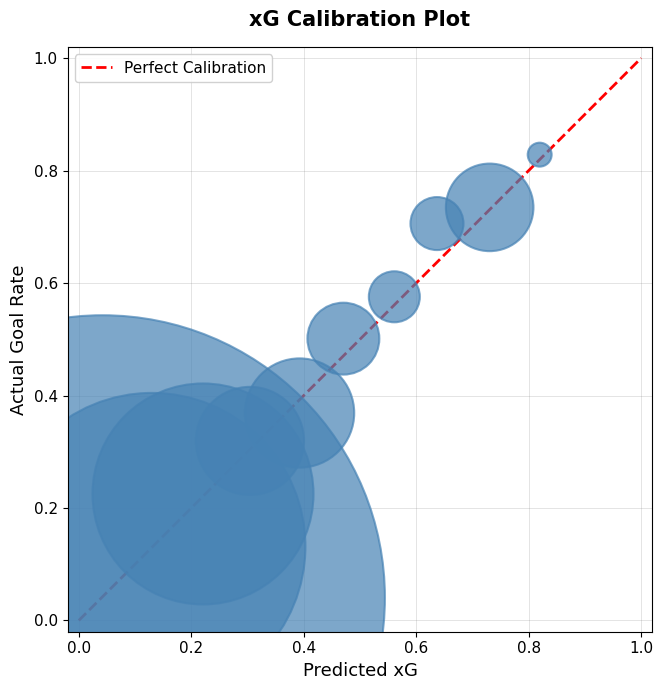

In [21]:
complex_model.plot_xg_calibration_styled(shots_df)

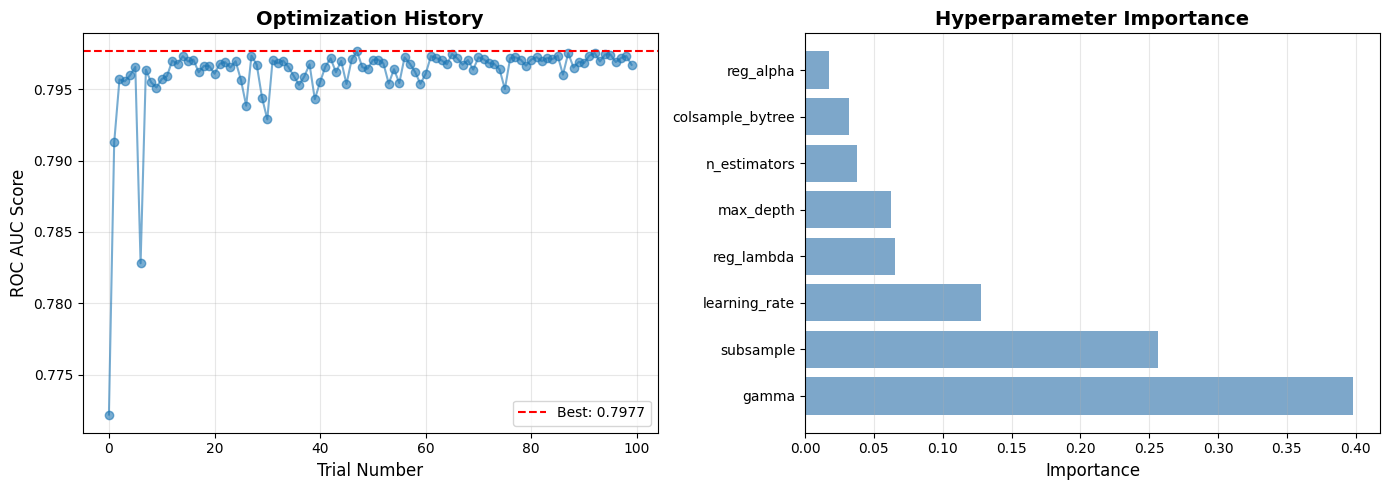

In [22]:
complex_model.plot_optimization_history()

In [23]:
complex_model._show_feature_importance()


TOP 10 MOST IMPORTANT FEATURES:
------------------------------------------------------------
inverse_dist_angle            : 0.2508
angle_to_goal                 : 0.2156
bodypart_Left Foot            : 0.0817
inverse_dist                  : 0.0788
bodypart_Right Foot           : 0.0781
dist_angle_interaction        : 0.0634
dist_to_goal                  : 0.0360
technique_Normal              : 0.0352
shot_difficulty               : 0.0323
lateral_distance              : 0.0251
------------------------------------------------------------


In [24]:
complex_model._show_least_important_features()


BOTTOM 10 LEAST IMPORTANT FEATURES:
------------------------------------------------------------
goal_angle_visible            : 0.0000
angle_squared                 : 0.0069
technique_Overhead Kick       : 0.0094
technique_Half Volley         : 0.0095
bodypart_Other                : 0.0095
technique_Volley              : 0.0095
dist_sq_angle                 : 0.0106
dist_squared                  : 0.0120
technique_Diving Header       : 0.0128
technique_Lob                 : 0.0227
------------------------------------------------------------


Analyze model predictions: where is the model having biggest errors

In [25]:
# After training, find where model is most wrong
df_with_xg = complex_model.add_xg_to_dataframe(shots_df)
df_with_xg['is_goal'] = (df_with_xg['shot_outcome'] == 'Goal').astype(int)
df_with_xg['xg_error'] = abs(df_with_xg['is_goal'] - df_with_xg['xG'])

# Biggest mispredictions
worst_predictions = df_with_xg.nlargest(20, 'xg_error')
worst_predictions[['player_name', 'dist_to_goal', 'angle_to_goal_deg', 
                         'shot_technique', 'xG', 'is_goal', 'xg_error']]

# Look for patterns - maybe you're missing a feature!

,player_name,dist_to_goal,angle_to_goal_deg,shot_technique,xG,is_goal,xg_error
53831,Diego Armando Valentin Contento,32.866092,13.810781,Half Volley,0.010351,1,0.989649
82446,Waldyr Pereira,34.853981,13.001598,Half Volley,0.010351,1,0.989649
16686,Andrés Iniesta Luján,30.761014,14.466717,Volley,0.013137,1,0.986863
70454,Daniel Alves da Silva,28.962389,15.694561,Half Volley,0.013718,1,0.986282
8731,Geum-Min Lee,36.090165,12.584440,Normal,0.013861,1,0.986139
9413,Marta Alexandra Cox Villarreal,34.050697,13.342697,Normal,0.013861,1,0.986139
53894,Tiago Manuel Dias Correia,35.037409,12.976449,Normal,0.013861,1,0.986139
77382,Ella Jade Mastrantonio,36.025130,12.629010,Normal,0.013861,1,0.986139
76196,Pablo Ezequiel De Blasis,39.684002,11.063599,Half Volley,0.013897,1,0.986103
4991,Emanuele Giaccherini,33.013482,13.610013,Normal,0.014385,1,0.985615


This are difficult shots that even though end up in a goal, there is nothing really surprising on it, just amazing players capable of converting shots that were almost impossible.

## 4. Results

### Analyze the dataframe

In [26]:
goals_df=shots_df[shots_df['shot_outcome'] == 'Goal']

In [27]:
goals_df.player_name.value_counts().head(10)

player_name
Lionel Andrés Messi Cuccittini         510
Luis Alberto Suárez Díaz               140
Neymar da Silva Santos Junior           89
Samuel Eto''o Fils                      66
Kylian Mbappé Lottin                    64
Thierry Henry                           63
Vivianne Miedema                        59
Cristiano Ronaldo dos Santos Aveiro     59
Pedro Eliezer Rodríguez Ledesma         56
Zlatan Ibrahimović                      50
Name: count, dtype: int64

Metrics calculation

In [28]:
# Comprehensive player performance analysis
player_stats = df_with_xg.groupby('player_name').agg({
    'xG': ['sum', 'count', 'mean'],
    'shot_outcome': lambda x: (x == 'Goal').sum()
}).reset_index()

# Flatten column names
player_stats.columns = ['player_name', 'total_xG', 'shots_taken', 'avg_xG_per_shot', 'actual_goals']

# Calculate multiple performance metrics
player_stats['goals_minus_xG'] = player_stats['actual_goals'] - player_stats['total_xG']

# Relative performance metrics (% percentage rates)
player_stats['xG_conversion_rate'] = (player_stats['actual_goals'] / player_stats['total_xG'] * 100).round(2)
player_stats['actual_conversion_rate'] = (player_stats['actual_goals'] / player_stats['shots_taken'] * 100).round(2)
player_stats['expected_conversion_rate'] = (player_stats['total_xG'] / player_stats['shots_taken'] * 100).round(2)

# Performance ratio (>1 means overperforming, <1 underperforming)
player_stats['performance_ratio'] = (player_stats['actual_goals'] / player_stats['total_xG']).round(3)

# *Performance ratio and xG conversion rate are basically the same (one in percentage and the other raw)

# Z-score for goals above/below expected (normalized performance)
player_stats['performance_z_score'] = (
    (player_stats['goals_minus_xG'] - player_stats['goals_minus_xG'].mean()) / 
    player_stats['goals_minus_xG'].std()
).round(3)

# Filter for players with meaningful sample size (e.g., at least 5 shots)
min_goals = 20
player_stats_filtered = player_stats[player_stats['actual_goals'] >= min_goals].copy()

In [29]:
# Sort by different metrics
print("=" * 80)
print("TOP 10 OVERPERFORMERS - By Absolute Goals Above xG")
print("=" * 80)
top_absolute = player_stats_filtered.nlargest(10, 'goals_minus_xG')
print(top_absolute[['player_name', 'actual_goals', 'total_xG', 'goals_minus_xG', 
                     'shots_taken', 'performance_ratio', 'xG_conversion_rate']].to_string(index=False))


TOP 10 OVERPERFORMERS - By Absolute Goals Above xG
                    player_name  actual_goals   total_xG  goals_minus_xG  shots_taken  performance_ratio  xG_conversion_rate
 Lionel Andrés Messi Cuccittini           510 382.344940      127.655060         2646              1.334              133.39
       Luis Alberto Suárez Díaz           140 102.476456       37.523544          635              1.366              136.62
           Kylian Mbappé Lottin            64  43.679821       20.320179          305              1.465              146.52
                  Thierry Henry            63  42.758972       20.241028          362              1.473              147.34
             Zlatan Ibrahimović            50  32.173664       17.826336          230              1.554              155.41
             Samuel Eto''o Fils            66  50.038044       15.961956          300              1.319              131.90
Pedro Eliezer Rodríguez Ledesma            56  43.201416       12.798584  

In [30]:
print("\n" + "=" * 80)
print("TOP 10 OVERPERFORMERS - By Performance Ratio (Goals/xG)")
print("=" * 80)
top_ratio = player_stats_filtered.nlargest(20, 'performance_ratio')
print(top_ratio[['player_name', 'actual_goals', 'total_xG', 'performance_ratio',
                 'goals_minus_xG', 'xG_conversion_rate', 'shots_taken']].to_string(index=False))


TOP 10 OVERPERFORMERS - By Performance Ratio (Goals/xG)
                      player_name  actual_goals   total_xG  performance_ratio  goals_minus_xG  xG_conversion_rate  shots_taken
                Gareth Frank Bale            25  13.320893              1.877       11.679107              187.68          123
               Zlatan Ibrahimović            50  32.173664              1.554       17.826336              155.41          230
                     Ivan Rakitić            29  19.105324              1.518        9.894676              151.79          226
                  Ousmane Dembélé            29  19.149771              1.514        9.850229              151.44          178
              Rubén Castro Martín            26  17.378334              1.496        8.621666              149.61          122
                Bojan Krkíc Pérez            26  17.525143              1.484        8.474857              148.36          138
              David Villa Sánchez            33  22.30

Trying to improve the performance ratio by considering the number of goals as well

In [73]:
print("\n" + "=" * 80)
print("TOP 10 OVERPERFORMERS - By Weighted Performance Score")
print("=" * 80)

# Create a weighted score that rewards both ratio AND volume
# Simple formula: performance_ratio * log(actual_goals)
# Log prevents massive goals from dominating, but still rewards volume
player_stats_filtered['weighted_performance'] = (
    player_stats_filtered['performance_ratio'] * 
    np.log(player_stats_filtered['actual_goals'])
).round(3)

top_ratio = player_stats_filtered.nlargest(20, 'weighted_performance')

print(top_ratio[['player_name', 'actual_goals', 'total_xG', 'performance_ratio',
                 'weighted_performance', 'shots_taken']].to_string(index=False))


TOP 10 OVERPERFORMERS - By Weighted Performance Score
                      player_name  actual_goals   total_xG  performance_ratio  weighted_performance  shots_taken
   Lionel Andrés Messi Cuccittini           510 378.838348              1.346                 8.392         2646
         Luis Alberto Suárez Díaz           140 102.309479              1.368                 6.760          635
                    Thierry Henry            63  42.512726              1.482                 6.140          362
             Kylian Mbappé Lottin            64  43.529289              1.470                 6.114          305
                Gareth Frank Bale            25  13.173776              1.898                 6.109          123
               Zlatan Ibrahimović            50  32.219322              1.552                 6.071          230
               Samuel Eto''o Fils            66  49.656109              1.329                 5.568          300
              David Villa Sánchez        

In [60]:
print("\n" + "=" * 80)
print("TOP 10 OVERPERFORMERS - By Z-Score (Statistical Significance)")
print("=" * 80)
top_zscore = player_stats_filtered.nlargest(10, 'performance_z_score')
print(top_zscore[['player_name', 'actual_goals', 'total_xG', 'performance_z_score',
                  'goals_minus_xG', 'performance_ratio', 'shots_taken']].to_string(index=False))


TOP 10 OVERPERFORMERS - By Z-Score (Statistical Significance)
                    player_name  actual_goals   total_xG  performance_z_score  goals_minus_xG  performance_ratio  shots_taken
 Lionel Andrés Messi Cuccittini           510 378.838348               61.128      131.161652              1.346         2646
       Luis Alberto Suárez Díaz           140 102.309479               17.565       37.690521              1.368          635
                  Thierry Henry            63  42.512726                9.547       20.487274              1.482          362
           Kylian Mbappé Lottin            64  43.529289                9.540       20.470711              1.470          305
             Zlatan Ibrahimović            50  32.219322                8.286       17.780678              1.552          230
             Samuel Eto''o Fils            66  49.656109                7.616       16.343891              1.329          300
Pedro Eliezer Rodríguez Ledesma            56  43.19862

In [ ]:
print("\n" + "=" * 80)
print("EFFICIENCY LEADERS - Best Conversion Rates (min 20 goals)")
print("=" * 80)
top_efficiency = player_stats_filtered.nlargest(10, 'actual_conversion_rate')
print(top_efficiency[['player_name', 'actual_goals', 'shots_taken', 'actual_conversion_rate',
                      'expected_conversion_rate', 'avg_xG_per_shot', 'performance_ratio']].to_string(index=False))


EFFICIENCY LEADERS - Best Conversion Rates (min 20 goals)
                      player_name  actual_goals  shots_taken  actual_conversion_rate  expected_conversion_rate  avg_xG_per_shot  performance_ratio
                    Nikita Parris            21           86                   24.42                     23.33         0.233301              1.047
         Francisco Alcácer García            23           98                   23.47                     19.73         0.197343              1.189
                    Kevin Gameiro            20           86                   23.26                     21.48         0.214811              1.083
         Luis Alberto Suárez Díaz           140          635                   22.05                     16.11         0.161117              1.368
               Samuel Eto''o Fils            66          300                   22.00                     16.55         0.165520              1.329
               Zlatan Ibrahimović            50          23

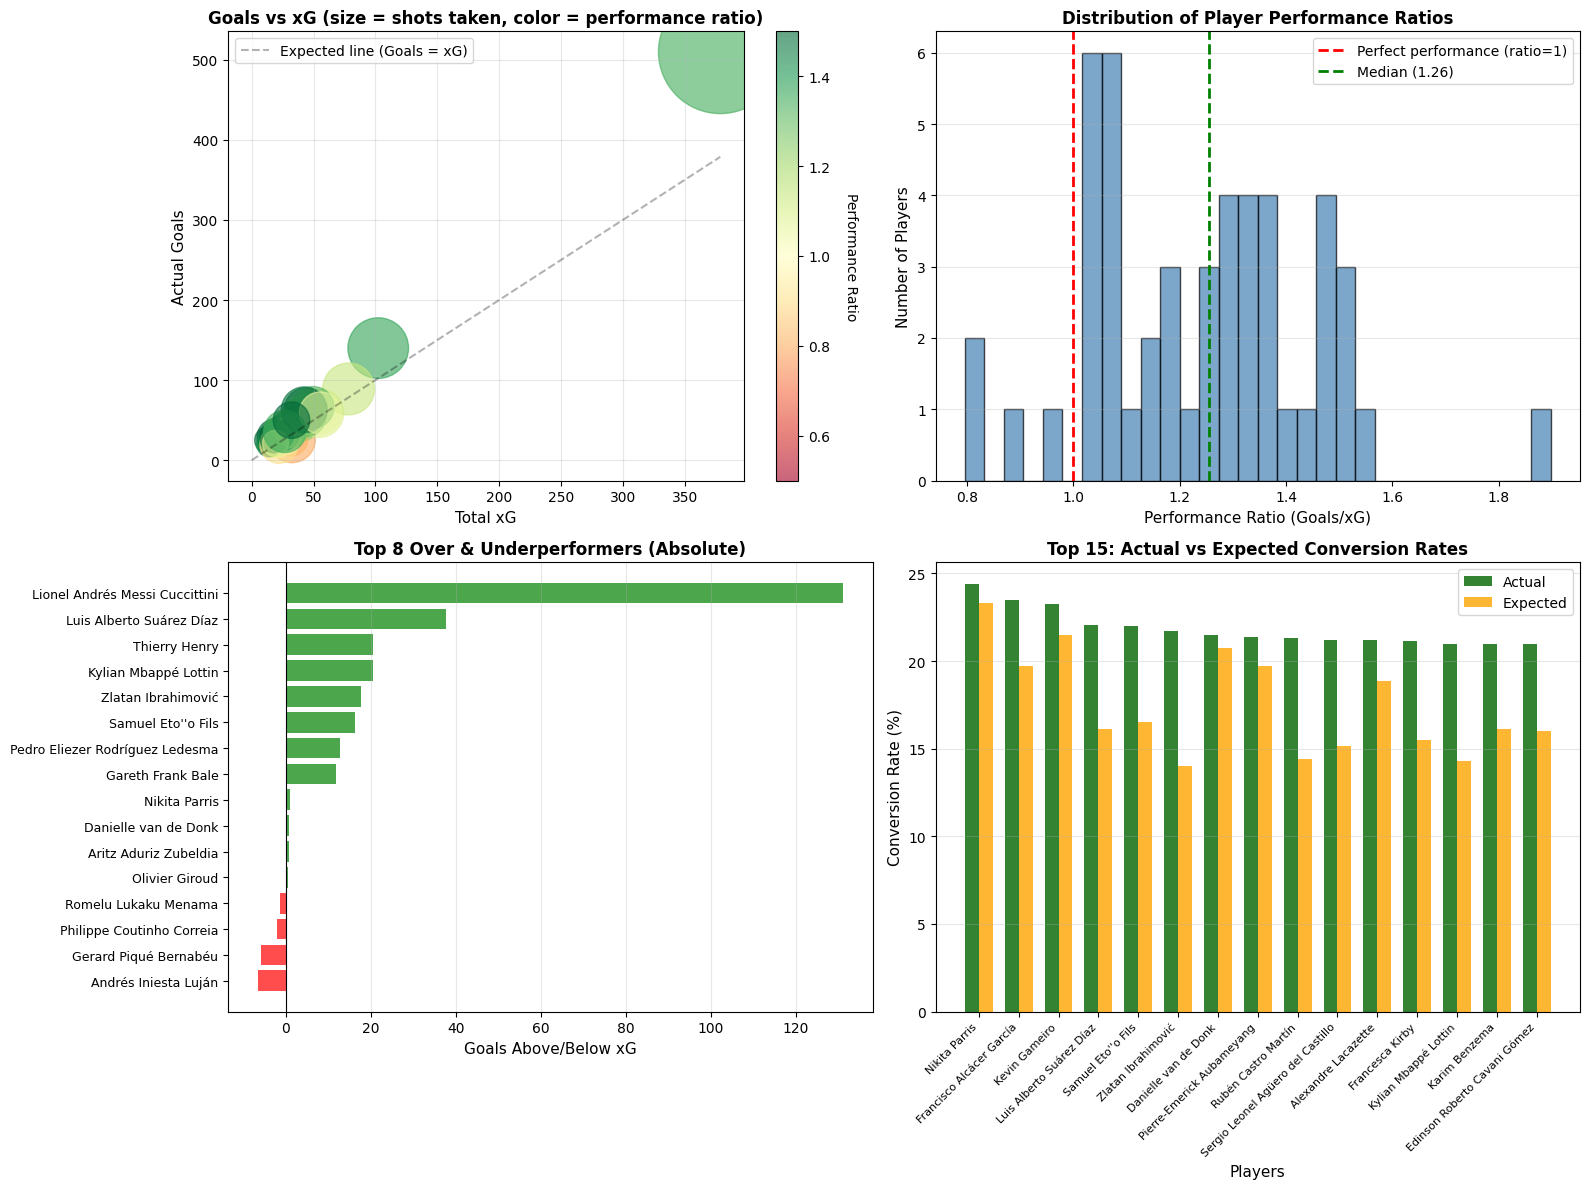

In [67]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Actual goals vs xG with performance ratio
ax1 = axes[0, 0]
scatter = ax1.scatter(player_stats_filtered['total_xG'], 
                     player_stats_filtered['actual_goals'],
                     c=player_stats_filtered['performance_ratio'],
                     s=player_stats_filtered['shots_taken']*3,
                     alpha=0.6, cmap='RdYlGn', vmin=0.5, vmax=1.5)
ax1.plot([0, player_stats_filtered['total_xG'].max()], 
         [0, player_stats_filtered['total_xG'].max()], 
         'k--', alpha=0.3, label='Expected line (Goals = xG)')
ax1.set_xlabel('Total xG', fontsize=11)
ax1.set_ylabel('Actual Goals', fontsize=11)
ax1.set_title('Goals vs xG (size = shots taken, color = performance ratio)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Performance Ratio', rotation=270, labelpad=20)

# 2. Distribution of performance ratio
ax2 = axes[0, 1]
ax2.hist(player_stats_filtered['performance_ratio'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Perfect performance (ratio=1)')
ax2.axvline(player_stats_filtered['performance_ratio'].median(), 
            color='green', linestyle='--', linewidth=2, label=f"Median ({player_stats_filtered['performance_ratio'].median():.2f})")
ax2.set_xlabel('Performance Ratio (Goals/xG)', fontsize=11)
ax2.set_ylabel('Number of Players', fontsize=11)
ax2.set_title('Distribution of Player Performance Ratios', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top/Bottom performers bar chart
ax3 = axes[1, 0]
top_bottom = pd.concat([
    player_stats_filtered.nlargest(8, 'goals_minus_xG'),
    player_stats_filtered.nsmallest(8, 'goals_minus_xG')
]).sort_values('goals_minus_xG')
colors = ['red' if x < 0 else 'green' for x in top_bottom['goals_minus_xG']]
ax3.barh(range(len(top_bottom)), top_bottom['goals_minus_xG'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(top_bottom)))
ax3.set_yticklabels(top_bottom['player_name'], fontsize=9)
ax3.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax3.set_xlabel('Goals Above/Below xG', fontsize=11)
ax3.set_title('Top 8 Over & Underperformers (Absolute)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Conversion rate comparison
ax4 = axes[1, 1]
top_converters = player_stats_filtered.nlargest(15, 'actual_conversion_rate')
x = np.arange(len(top_converters))
width = 0.35
bars1 = ax4.bar(x - width/2, top_converters['actual_conversion_rate'], 
                width, label='Actual', alpha=0.8, color='darkgreen')
bars2 = ax4.bar(x + width/2, top_converters['expected_conversion_rate'], 
                width, label='Expected', alpha=0.8, color='orange')
ax4.set_xlabel('Players', fontsize=11)
ax4.set_ylabel('Conversion Rate (%)', fontsize=11)
ax4.set_title('Top 15: Actual vs Expected Conversion Rates', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(top_converters['player_name'], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Plotting different stuff

To analyze the heatmap by technique we need to train for every technique separetly, otherwise it is cnverted to one-hot encoding in previous steps and it cannot be analyzed

##### 5.1 Train model per technique

In [31]:
techniques = ['Half Volley', 'Normal', 'Volley', 'Overhead Kick',
              'Diving Header', 'Backheel', 'Lob']
models = {}
metrics_comparison = []

In [32]:
shots_df.shot_technique.value_counts()

shot_technique
Normal           68064
Half Volley      11604
Volley            5588
Lob                837
Overhead Kick      450
Backheel           343
Diving Header      329
Name: count, dtype: int64

In [33]:
for technique in techniques:

    # Filter data for this technique
    technique_data = shots_df[shots_df['shot_technique'] == technique].copy()
    
    # Train a model WITHOUT the technique column (since it's constant)
    model = AdvancedXGModel(n_trials=50, cv_folds=3)
    
    # Temporarily remove shot_technique column for training
    technique_data_train = technique_data.drop(columns=['shot_technique'], errors='ignore')
    
    metrics = model.train(technique_data_train, test_size=0.2, verbose=False)
    
    models[technique] = model
    metrics_comparison.append({
        'technique': technique,
        'roc_auc': metrics['roc_auc'],
        'brier_score': metrics['brier_score'],
        'samples': len(technique_data)})

In [34]:
metrics_comparison

[{'technique': 'Half Volley',
  'roc_auc': 0.8081128317684836,
  'brier_score': 0.0779284448123484,
  'samples': 11604},
 {'technique': 'Normal',
  'roc_auc': 0.7860799336013412,
  'brier_score': 0.08221687298607676,
  'samples': 68064},
 {'technique': 'Volley',
  'roc_auc': 0.7294772966101072,
  'brier_score': 0.09988428526524062,
  'samples': 5588},
 {'technique': 'Overhead Kick',
  'roc_auc': 0.7667682926829269,
  'brier_score': 0.07681345786445917,
  'samples': 450},
 {'technique': 'Diving Header',
  'roc_auc': 0.6703296703296703,
  'brier_score': 0.1533418191653444,
  'samples': 329},
 {'technique': 'Backheel',
  'roc_auc': 0.7730414746543779,
  'brier_score': 0.0900120103793068,
  'samples': 343},
 {'technique': 'Lob',
  'roc_auc': 0.6850712150518727,
  'brier_score': 0.20091384211934515,
  'samples': 837}]

Generating heatmap for Half Volley...
Generating heatmap for Normal...
Generating heatmap for Volley...
Generating heatmap for Overhead Kick...
Generating heatmap for Diving Header...
Generating heatmap for Backheel...
Generating heatmap for Lob...


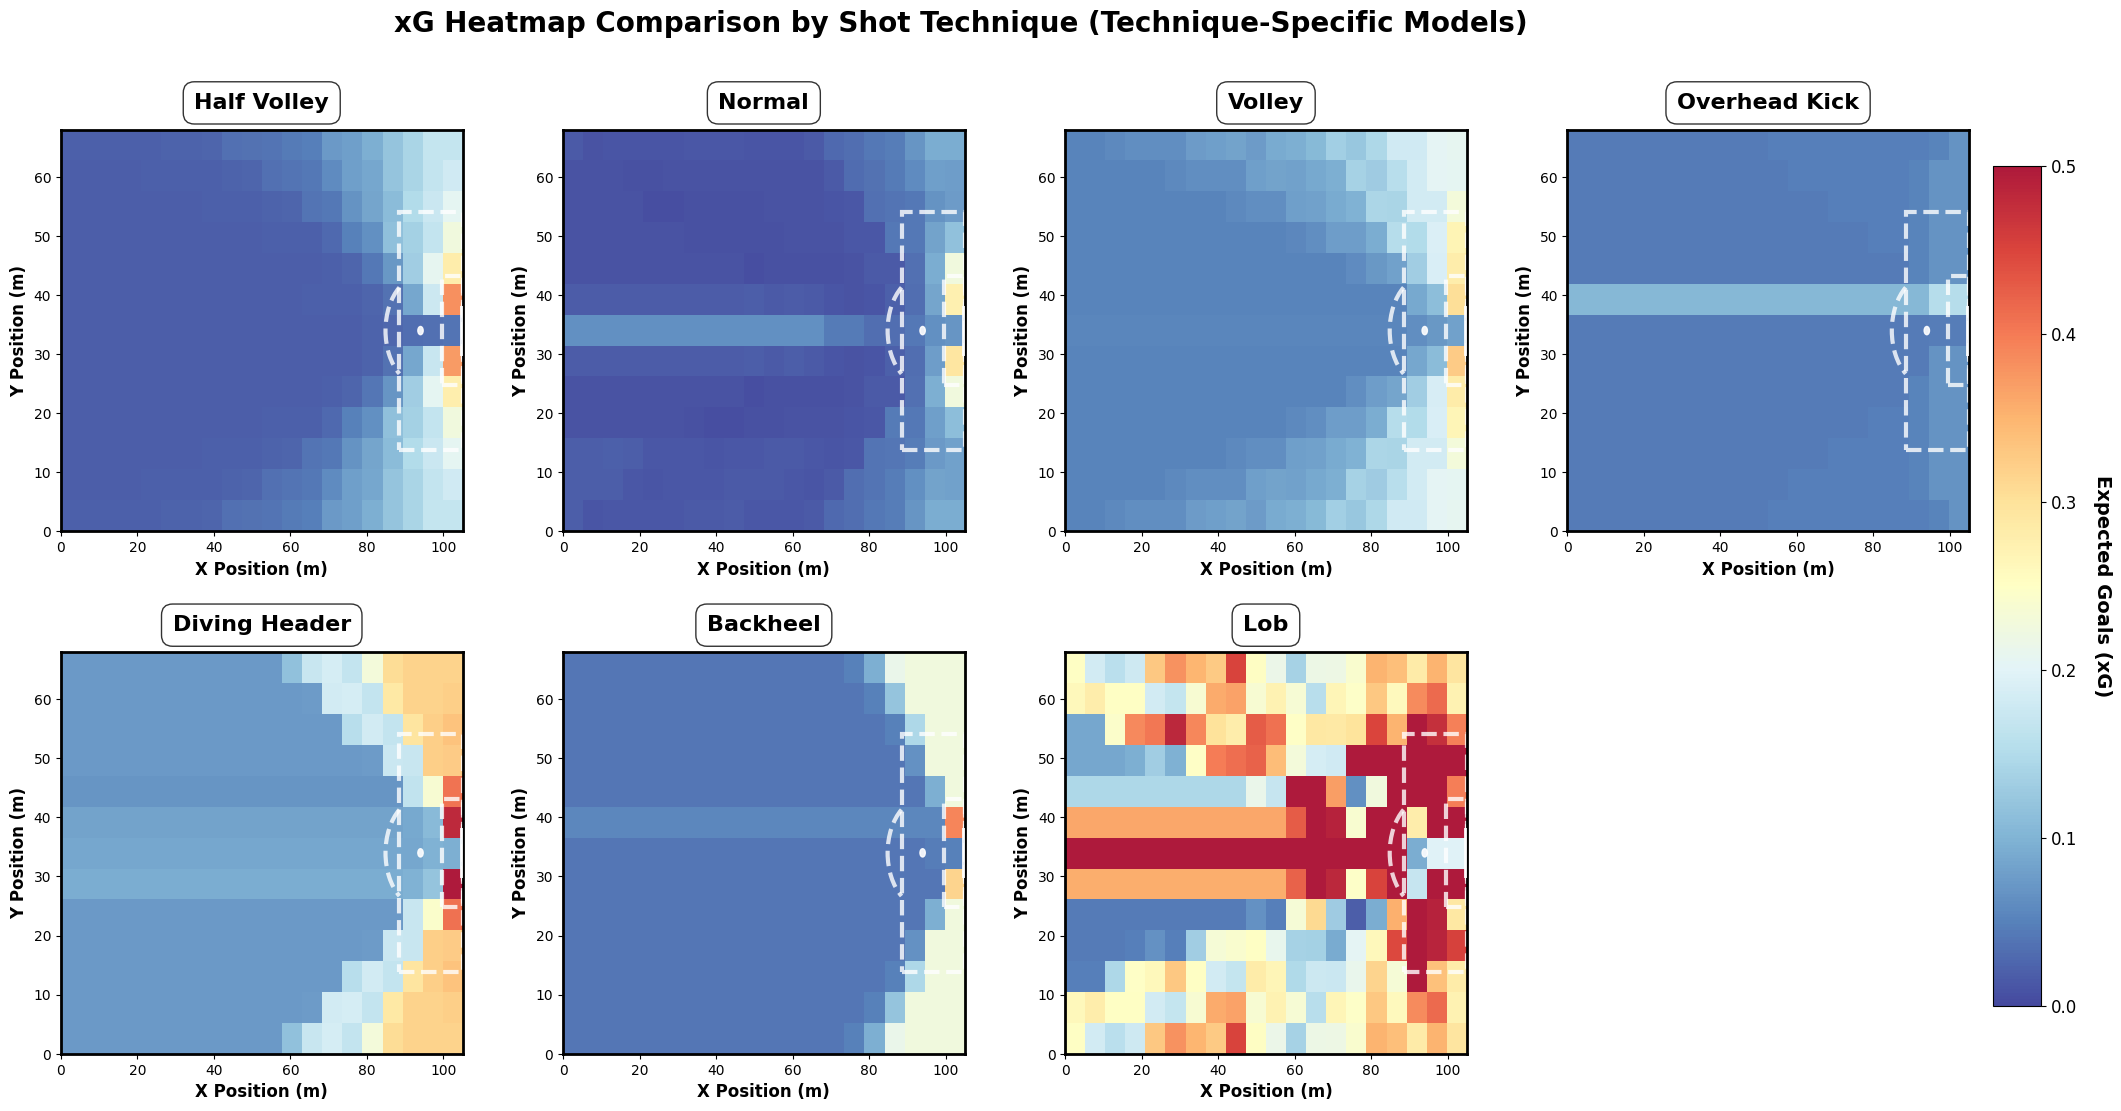

In [37]:
# Create larger figure for better visibility
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for idx, technique in enumerate(techniques):
    print(f"Generating heatmap for {technique}...")
    
    xg_grid, x_edges, y_edges = generate_xg_heatmap(models[technique], shots_df, technique)
    
    ax = axes[idx]
    
    # Plot heatmap with higher alpha for better visibility
    im = ax.imshow(xg_grid, extent=[0, 105, 0, 68], origin='lower',
                   cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.5, alpha=0.9)
    
    # Field dimensions (half pitch, attacking right)
    # Penalty area: 16.5m from goal line, 40.3m wide (centered on 34m)
    penalty_box = plt.Rectangle((88.5, 13.85), 16.5, 40.3,
                                linewidth=3, edgecolor='white', facecolor='none', 
                                linestyle='--', alpha=0.8)
    ax.add_patch(penalty_box)
    
    # Goal area (6-yard box): 5.5m from goal line, 18.32m wide
    goal_box = plt.Rectangle((99.5, 24.84), 5.5, 18.32,
                             linewidth=3, edgecolor='white', facecolor='none',
                             linestyle='--', alpha=0.8)
    ax.add_patch(goal_box)
    
    # Penalty spot (11m from goal line, centered)
    penalty_spot = plt.Circle((94, 34), 0.7, color='white', zorder=10, alpha=0.9)
    ax.add_patch(penalty_spot)
    
    # Penalty arc (radius 9.15m from penalty spot)
    penalty_arc = plt.matplotlib.patches.Arc((94, 34), 18.3, 18.3, 
                                             angle=0, theta1=127, theta2=233,
                                             linewidth=3, edgecolor='white', 
                                             facecolor='none', linestyle='--', alpha=0.8)
    ax.add_patch(penalty_arc)
    
    # Goal line - thicker and white
    ax.plot([105, 105], [30.34, 37.66], 'white', linewidth=5, zorder=10, alpha=0.9)
    
    # Enhanced title with background
    ax.set_title(f'{technique}', fontsize=16, fontweight='bold', pad=15,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('X Position (m)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 68)
    ax.grid(False)
    
    # Add frame
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Hide the 8th subplot (we only have 7 techniques)
axes[7].axis('off')

# Adjust overall layout to make room for colorbar
plt.subplots_adjust(right=0.92, wspace=0.25, hspace=0.3)

# Add colorbar clearly on the right side of all subplots
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Expected Goals (xG)', rotation=270, labelpad=25, 
               fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.suptitle('xG Heatmap Comparison by Shot Technique (Technique-Specific Models)', 
             fontsize=20, fontweight='bold', y=0.98)
plt.show()


### 5.2. Use the trained model for all techniques

In [51]:
from nodes.plot import generate_xg_heatmap_from_data, verify_xg_heatmaps, plot_distance_comparison

ImportError: cannot import name 'generate_xg_heatmap_from_data' from 'nodes.plot' (/Users/rodrigo/football-data-analytics/football_xG/xG/nodes/plot.py)

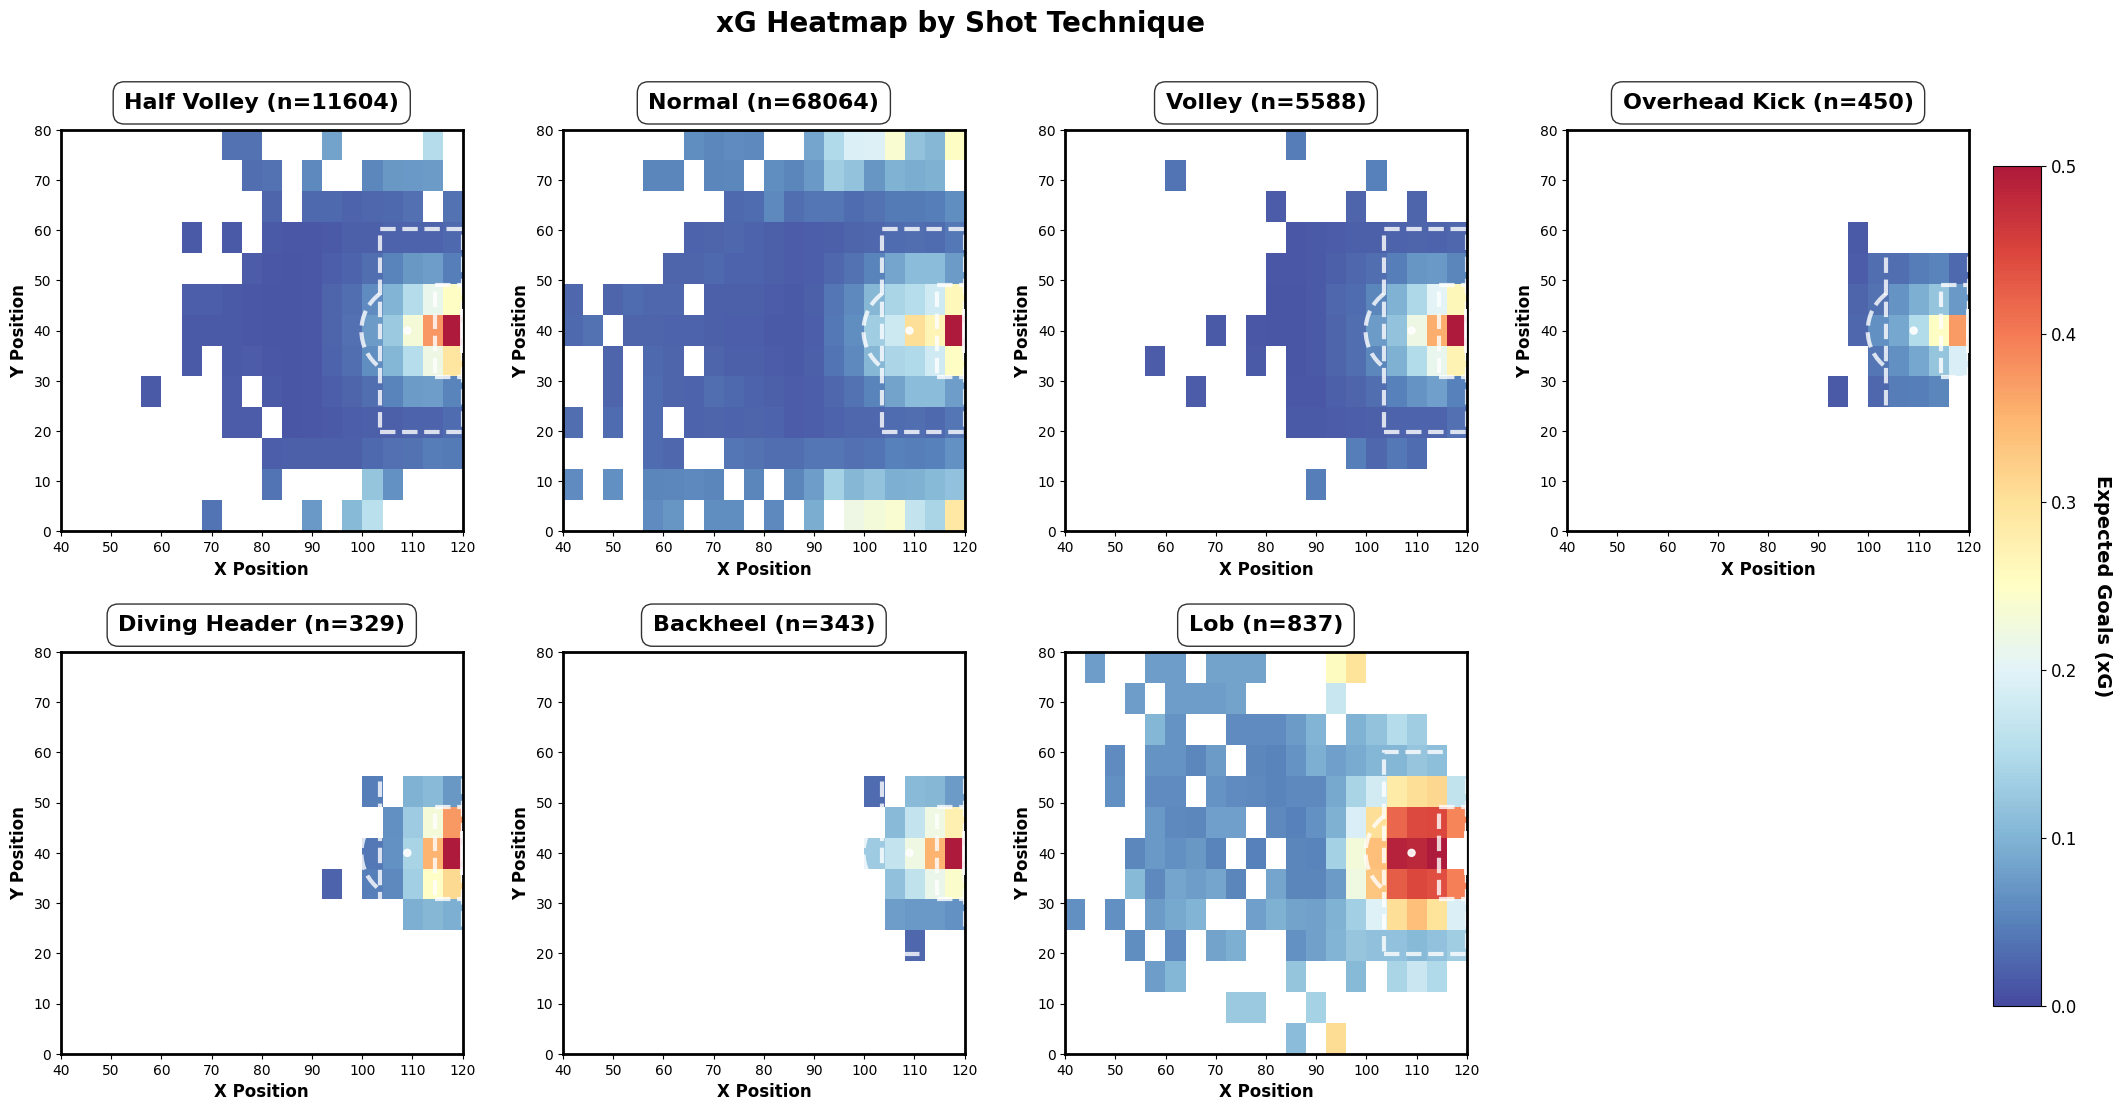

In [ ]:
# Get all unique techniques
techniques = shots_with_xg['shot_technique'].unique()

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, technique in enumerate(techniques):
    xg_grid, x_edges, y_edges = generate_xg_heatmap_from_data(shots_with_xg, technique)
    
    if xg_grid is None:
        axes[idx].axis('off')
        continue
    
    ax = axes[idx]
    
    # Plot heatmap with correct extent
    im = ax.imshow(xg_grid, extent=[40, 120, 0, 80], origin='lower',
                   cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.5, alpha=0.9)
    
    # Adjust field markings to your coordinate system
    # Goal at x=120, centered at y=40
    penalty_box = plt.Rectangle((103.5, 19.85), 16.5, 40.3,
                                linewidth=3, edgecolor='white', facecolor='none', 
                                linestyle='--', alpha=0.8)
    ax.add_patch(penalty_box)
    
    goal_box = plt.Rectangle((114.5, 30.84), 5.5, 18.32,
                             linewidth=3, edgecolor='white', facecolor='none',
                             linestyle='--', alpha=0.8)
    ax.add_patch(goal_box)
    
    penalty_spot = plt.Circle((109, 40), 0.7, color='white', zorder=10, alpha=0.9)
    ax.add_patch(penalty_spot)
    
    penalty_arc = plt.matplotlib.patches.Arc((109, 40), 18.3, 18.3, 
                                             angle=0, theta1=127, theta2=233,
                                             linewidth=3, edgecolor='white', 
                                             facecolor='none', linestyle='--', alpha=0.8)
    ax.add_patch(penalty_arc)
    
    # Goal line
    ax.plot([120, 120], [36.34, 43.66], 'white', linewidth=5, zorder=10, alpha=0.9)
    
    n_shots = len(shots_with_xg[shots_with_xg['shot_technique'] == technique])
    ax.set_title(f'{technique} (n={n_shots})', fontsize=16, fontweight='bold', pad=15,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('X Position', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position', fontsize=12, fontweight='bold')
    ax.set_xlim(40, 120)
    ax.set_ylim(0, 80)
    ax.grid(False)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Hide unused subplots
for idx in range(len(techniques), len(axes)):
    axes[idx].axis('off')

plt.subplots_adjust(right=0.92, wspace=0.25, hspace=0.3)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Expected Goals (xG)', rotation=270, labelpad=25, 
               fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.suptitle('xG Heatmap by Shot Technique', 
             fontsize=20, fontweight='bold', y=0.98)
plt.show()

XG HEATMAP VERIFICATION REPORT

1. OVERALL DATASET
--------------------------------------------------------------------------------
Total shots: 87,215
Shots with xG values: 87,215
Missing xG values: 0

xG Statistics:
  Mean xG: 0.1120
  Median xG: 0.0608
  Min xG: 0.0091
  Max xG: 0.8592

2. COORDINATE RANGES
--------------------------------------------------------------------------------
X range: [40.0, 120.0]
Y range: [0.3, 80.0]
Distance range: [0.4, 82.3]

Shots outside [40, 120] x [0, 80] grid:
  Outside X: 0
  Outside Y: 0

3. TECHNIQUE DISTRIBUTION
--------------------------------------------------------------------------------
  Normal              : 68,064 shots (78.04%)
  Half Volley         : 11,604 shots (13.31%)
  Volley              :  5,588 shots ( 6.41%)
  Lob                 :    837 shots ( 0.96%)
  Overhead Kick       :    450 shots ( 0.52%)
  Backheel            :    343 shots ( 0.39%)
  Diving Header       :    329 shots ( 0.38%)

4. PER-TECHNIQUE XG STATISTICS
--

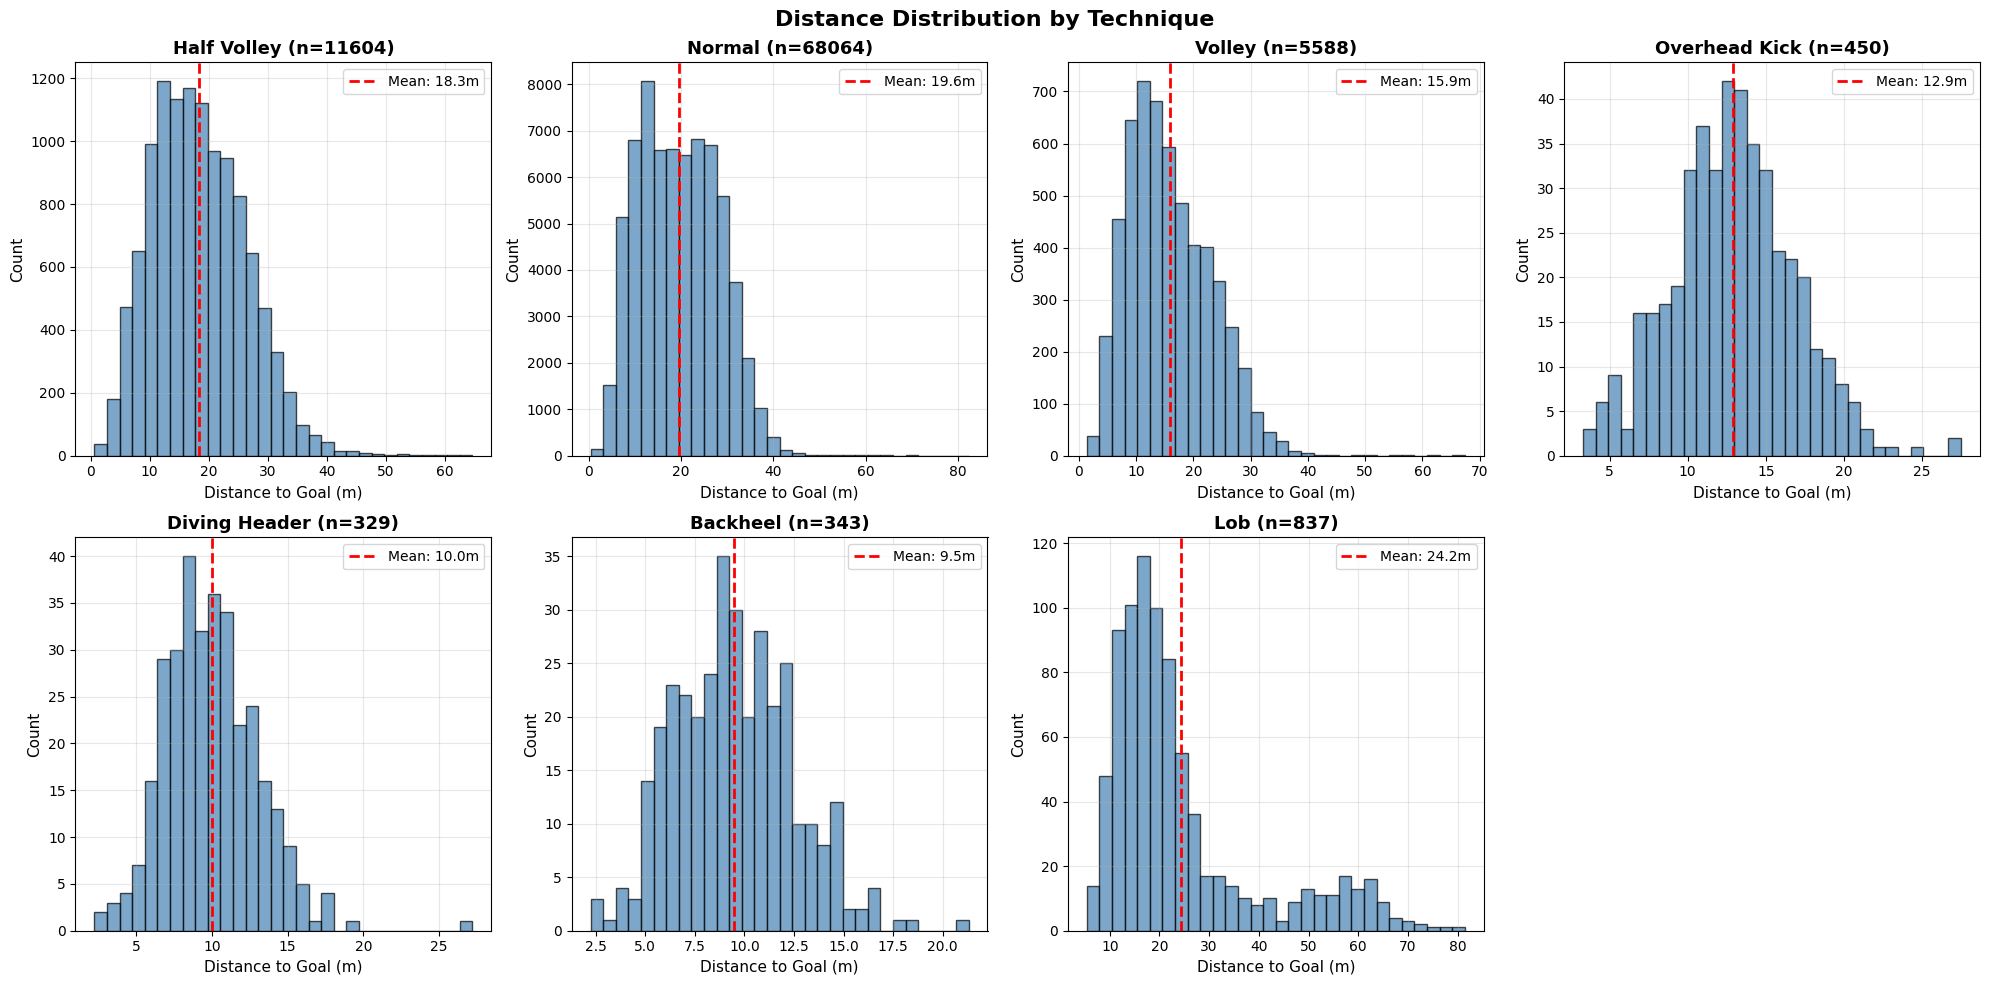

In [ ]:
# Run the verification
verify_xg_heatmaps(shots_with_xg)

# Run the distance plot
plot_distance_comparison(shots_with_xg)